# Homework Assignment Solution: Logistic Regression

BINF 6210/8210: Machine Learning for Bioinformatics
___

This notebook provides one defensible solution. Alternative scientifically justified choices may receive full credit.

## Problem 2 — Predicting Diabetes Using Logistic Regression

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## Load the data

In [2]:
DATA_FILE = Path("../../data/Pima Indians Diabetes Dataset.csv")

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Part A: Explore the biological data

First, examine the sample size, predictor variables, outcome distribution, summary statistics, and distributions of the predictors.

In [4]:
print("Number of observations:", df.shape[0])
print("Number of predictor variables:", df.shape[1] - 1)

print("\nOutcome counts:")
print(df["Outcome"].value_counts().sort_index())

print("\nOutcome proportions:")
print(df["Outcome"].value_counts(normalize=True).sort_index())

Number of observations: 768
Number of predictor variables: 8

Outcome counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [ ]:
df.describe().T

### Plot the predictor distributions

Histograms are useful for identifying skewness, unusual values, and values concentrated at zero.

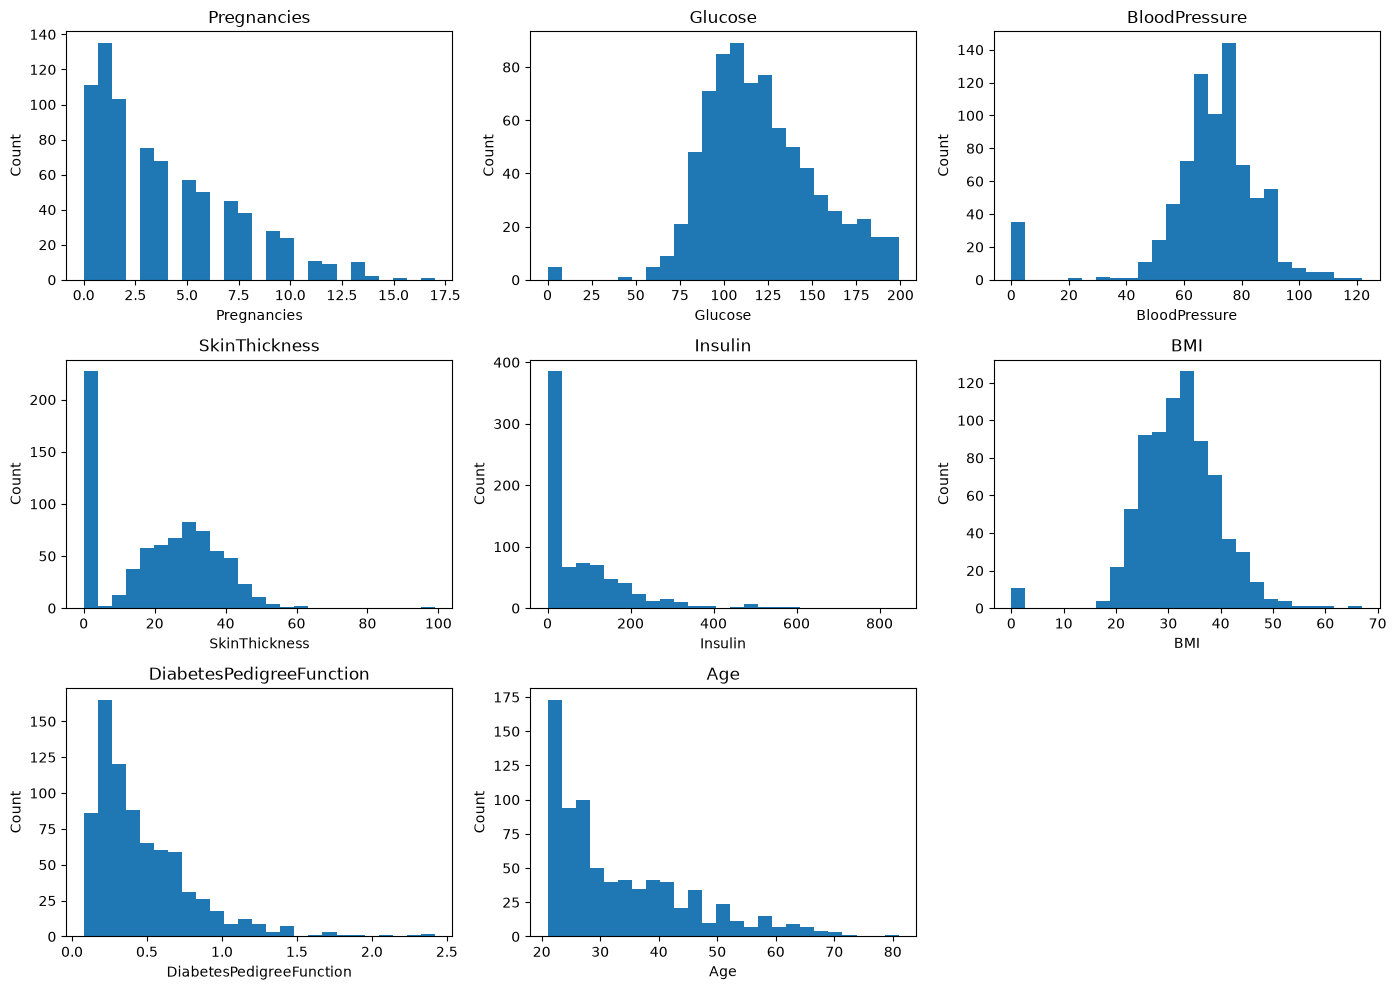

In [5]:
predictor_columns = [c for c in df.columns if c != "Outcome"]

n_cols = 3
n_rows = int(np.ceil(len(predictor_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, predictor_columns):
    ax.hist(df[col].dropna(), bins=25)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(predictor_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Identify biologically implausible zero values

A value of zero is meaningful for `Pregnancies`, but zero is generally not a plausible measured value for variables such as:

- glucose concentration,
- blood pressure,
- skin thickness,
- insulin, and
- BMI.

For this assignment problem, these zeros will be treated as missing measurements.

**Important methodological point:** We will replace these zeros with `NaN` before the split, but we will **not calculate the imputation values yet**. The median values used for imputation must be learned from the training data only.

In [6]:
 zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Number of zero values:")
for col in zero_as_missing:
    print(f"{col:15s}: {(df[col] == 0).sum()}")

Number of zero values:
Glucose        : 5
BloodPressure  : 35
SkinThickness  : 227
Insulin        : 374
BMI            : 11


In [7]:
df_clean = df.copy()

df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("Missing values after recoding implausible zeros:")
df_clean.isna().sum()

Missing values after recoding implausible zeros:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Expected interpretation

We should recognize that blindly treating all zeros as valid measurements can be problematic. At the same time, zero pregnancies is a legitimate value and should **not** be converted to missing.

Replacing known impossible-value codes with `NaN` does not itself estimate anything from the full dataset. The actual median imputation will occur later, inside a pipeline fitted only to the training data.

# Part B: Prepare the data

Separate predictors and response, then create a stratified 75/25 train/test split.

`stratify=y` helps preserve approximately the same proportion of diabetes cases in both subsets.

In [8]:
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=6210
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining outcome proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest outcome proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (576, 8)
Test set: (192, 8)

Training outcome proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Test outcome proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## Build a leakage-safe preprocessing/modeling pipeline

The order is:

$$
	\text{impute median} \rightarrow \text{standardization} \rightarrow \text{build model}.
$$

Because all three steps are inside a `Pipeline`, the imputation medians and scaling parameters are learned from the **training set only** during `fit()`.

In [9]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000))
])

### Why preprocessing the complete dataset would cause leakage

Suppose we calculated the median and mean/standard deviation using all observations before creating the test set. The resulting preprocessing parameters would contain information from observations that are supposed to be unseen during model development.

Putting the preprocessing steps inside the pipeline prevents this problem.

# Part C: Fit the logistic-regression model

In [10]:
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")
print(f"Train - test:      {train_accuracy - test_accuracy:.4f}")

Training accuracy: 0.7760
Test accuracy:     0.7708
Train - test:      0.0052


### Interpretation

If training and test accuracy are reasonably similar, there is no obvious evidence of **severe** overfitting.

However, this conclusion should be limited. Similar training and test accuracy does not establish clinical usefulness, nor does accuracy by itself fully characterize classifier performance.

# Part D: Interpret predicted probabilities

`predict_proba()` returns the estimated probability for each class.

Because diabetes is class 1,

```python
predict_proba(X_test)[:, 1]
```

gives the estimated

$$
P(Y=1 \mid X)=P(	\text{diabetes} \mid X).
$$

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

prediction_table = X_test.copy()
prediction_table["true_outcome"] = y_test
prediction_table["P_diabetes"] = y_prob
prediction_table["predicted_class"] = y_pred

prediction_table.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,true_outcome,P_diabetes,predicted_class
175,8,179.0,72.0,42.0,130.0,32.7,0.719,36,1,0.891580,1
407,0,101.0,62.0,NaN,NaN,21.9,0.336,25,0,0.040739,0
647,0,179.0,50.0,36.0,159.0,37.8,0.455,22,1,0.797340,1
285,7,136.0,74.0,26.0,135.0,26.0,0.647,51,0,0.460442,0
673,3,123.0,100.0,35.0,240.0,57.3,0.880,22,0,0.810470,1


## Find three illustrative individuals

We select:

1. the lowest predicted probability;
2. the probability closest to 0.5;
3. the highest predicted probability.

In [12]:
idx_low = np.argmin(y_prob)
idx_mid = np.argmin(np.abs(y_prob - 0.5))
idx_high = np.argmax(y_prob)

selected_positions = [idx_low, idx_mid, idx_high]
selected_labels = [
    "Lowest predicted probability",
    "Closest to 0.5",
    "Highest predicted probability"
]

selected = prediction_table.iloc[selected_positions].copy()
selected.insert(0, "case_type", selected_labels)

selected

,case_type,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,true_outcome,P_diabetes,predicted_class
97,Lowest predicted probability,1,71.0,48.0,18.0,76.0,20.4,0.323,22,0,0.013462,0
266,Closest to 0.5,0,138.0,NaN,NaN,NaN,36.3,0.933,25,1,0.517515,1
228,Highest predicted probability,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0,0.978819,1


### `predict()` versus `predict_proba()`

- `predict_proba()` returns estimated class probabilities.
- `predict()` converts the model output into a class label using the classifier's decision rule.

For standard binary logistic regression, a predicted probability near 0.5 lies close to the default decision boundary. Such a sample is therefore relatively uncertain **with respect to the model's class decision**.

A probability near 0 or 1 represents a more confident model prediction, but it does not guarantee that the prediction is correct.

# Part E: Interpret standardized coefficients

Because `StandardScaler` is applied before logistic regression, the fitted coefficients correspond to standardized predictor values.

For predictor $X_j$,

$$
\log\left(\frac{p}{1-p}\right)
=
\theta_0 + \theta_1 X_1 + \cdots+\theta_j X_j + \cdots.
$$

The odds ratio associated with a one-standard-deviation increase in predictor $X_j$, holding the other predictors constant, is

$$
\text{odds ratio}_j=e^{\theta_j}.
$$

In [13]:
coefficients = model.named_steps["logistic"].coef_[0]

coef_table = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
}).sort_values("Coefficient", ascending=False)

coef_table.round(4)

,Predictor,Coefficient,Odds_Ratio
1,Glucose,1.1535,3.1694
5,BMI,0.6278,1.8735
0,Pregnancies,0.3565,1.4284
6,DiabetesPedigreeFunction,0.3333,1.3956
7,Age,0.1785,1.1955
3,SkinThickness,0.0462,1.0473
4,Insulin,-0.0577,0.9439
2,BloodPressure,-0.0791,0.9239


## Three largest positive coefficients

In [14]:
coef_table.nlargest(3, "Coefficient").round(4)

,Predictor,Coefficient,Odds_Ratio
1,Glucose,1.1535,3.1694
5,BMI,0.6278,1.8735
0,Pregnancies,0.3565,1.4284


## Three largest negative coefficients

In [15]:
coef_table.nsmallest(3, "Coefficient").round(4)

,Predictor,Coefficient,Odds_Ratio
2,BloodPressure,-0.0791,0.9239
4,Insulin,-0.0577,0.9439
3,SkinThickness,0.0462,1.0473


### Example interpretation

The exact feature with the largest positive coefficient should be identified from the table above.

If, for example, the coefficient for a standardized predictor were \(0.80\),

$$
e^{0.80} \approx 2.23.
$$

The appropriate interpretation would be:

> Holding the other predictors constant, a one-standard-deviation increase in this predictor is associated with approximately 2.23 times the odds of diabetes.

It would **not** be correct to say that the probability of diabetes increases by 123%.

# Part F: Scientific interpretation

A strong answer should address all three points below.

### 1. Which predictors appear important?

Students should identify the predictors with relatively large positive or negative standardized coefficients. The wording should be cautious:

> These predictors show relatively strong conditional associations with the model's predicted log-odds of diabetes.

### 2. Does a large coefficient imply causality?

No.

The fitted coefficients describe associations conditional on the predictors included in the model. They do not establish that changing a predictor would cause a change in diabetes status.

Possible explanations for an observed association include:

- confounding;
- correlations among predictors;
- selection effects;
- measurement error;
- unmeasured variables; and
- underlying biological relationships.

### 3. What limitations should be considered?

Reasonable answers include:

- representativeness of the study population;
- missing or implausible measurements;
- sample size;
- correlated predictors;
- lack of external validation;
- potential confounding;
- differences between prediction and causal inference; and
- the need for prospective validation before clinical use.

# Final summary

This exercise illustrates several core properties of logistic regression:

1. Logistic regression predicts a **probability** for a binary outcome.
2. The linear predictor models **log-odds**, not probability directly.
3. A 0.5 probability threshold can convert probabilities into class labels.
4. With standardized predictors, $e^{\theta_j}$ is the odds ratio associated with a one-standard-deviation increase in $X_j$, holding the other predictors constant.
5. An odds ratio is **not** the same as a probability ratio.
6. Predictive associations should not automatically be interpreted as causal biological effects.